In [1]:
# # Load the first time series response = 
# from io import BytesIO
# import numpy as np
# import requests


# response = requests.get("https://zenodo.org/records/10897398/files/smoothing_ts1.npy?download=1") 
# response.raise_for_status() 
# smoothing_ts1 = np.load(BytesIO(response.content)) 
# print(len(smoothing_ts1))

# response = requests.get("https://zenodo.org/records/10897398/files/smoothing_ts4_4.npy?download=1") 
# response.raise_for_status() 
# smoothing_ts2 = np.load(BytesIO(response.content)) 
# print(len(smoothing_ts2))

# np.save("3.ts1.npy",smoothing_ts1)
# np.save("3.ts2.npy",smoothing_ts2)

144
1000


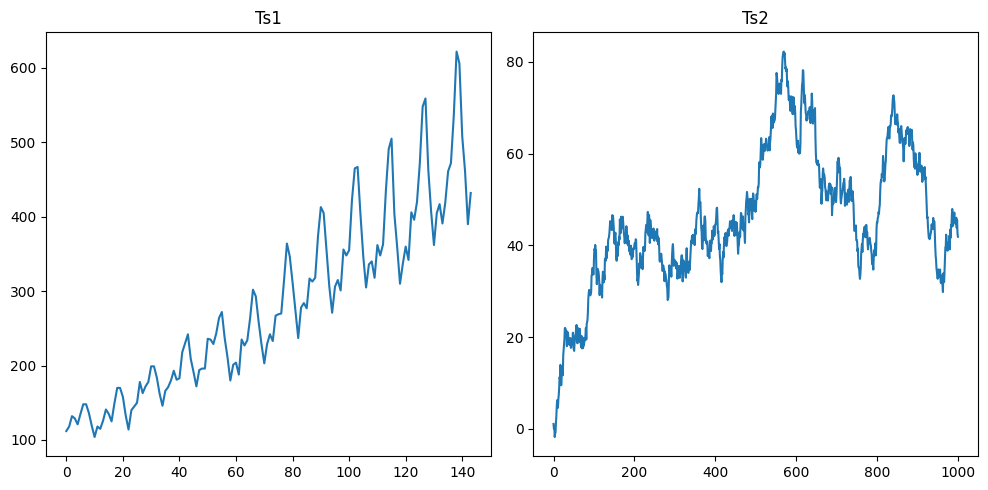

In [13]:
from matplotlib import pyplot as plt
import numpy as np

ts1 = np.load("3.ts1.npy")
ts2 = np.load("3.ts2.npy")

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(ts1)
plt.title("Ts1")
plt.subplot(1,2,2)
plt.plot(ts2)
plt.title("Ts2")
plt.tight_layout()

ADF stat: -7.349, p-value: 0.0000
Stationary


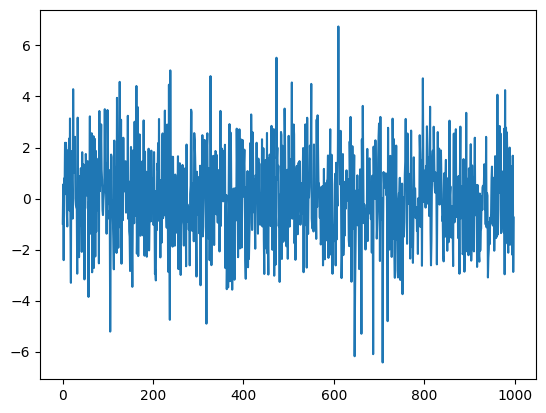

In [26]:
from statsmodels.tsa.stattools import adfuller
ts2_diff = np.diff(ts2)
stat, p = adfuller(ts2_diff)[:2]
print(f"ADF stat: {stat:.3f}, p-value: {p:.4f}")
print("Stationary" if p < 0.05 else "Non-stationary")

# ts2 точно является броуновским движением
# и по графику, и по adfuller тесту видно что производная сигнала
# является белым шумом
plt.plot(ts2_diff)

In [34]:
mytime1 = np.zeros_like(ts1)
mytime2 = np.zeros_like(ts2)

ts1_train,ts1_test = ts1[:-5],ts1[-5:]
ts2_train,ts2_test = ts2[:-30],ts2[-30:]


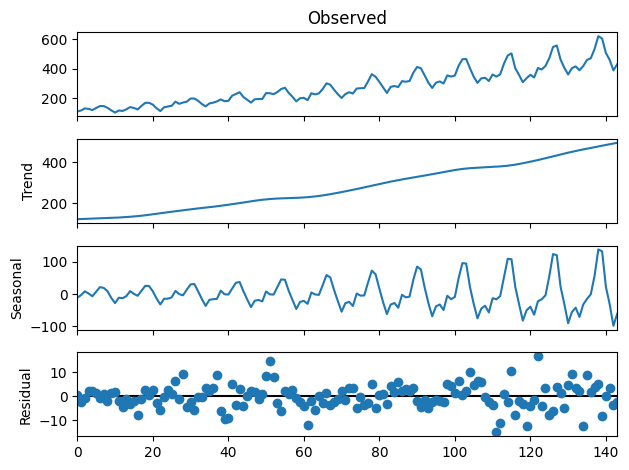

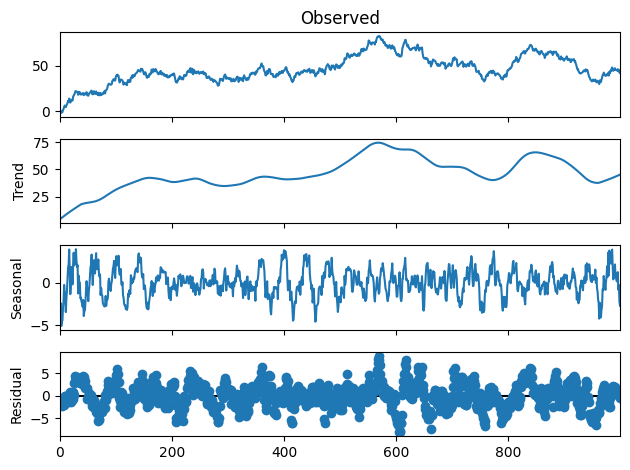

In [24]:
from statsmodels.tsa.seasonal import STL

# ts1 точно имеет тренд и сезонность, это те же данные с пасажирами
# ts1 и тренд и сезонность носит аддитивный характер
STL(ts1,period=12).fit().plot()
# ts2 является броуновским движеним, поэтому у него нет ни тренда, ни сезонности
STL(ts2,period=40).fit().plot()
plt.show()

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from statsmodels.tsa.statespace.structural import UnobservedComponents

def test_smoothening(train, test):
    K = len(test)
    N = len(train)
    
    # Define models to test
    # Note: statsmodels HW models don't use 'disp', but UnobservedComponents does.
    models_config = [
        ("Simple Exponential Smoothing", SimpleExpSmoothing, {}),
        ("Holt Linear Trend", ExponentialSmoothing, {"trend": 'add'}),
        ("Holt-Winters (Add Seasonal)", ExponentialSmoothing, {
            "trend": 'add', 
            "seasonal": 'add', 
            "seasonal_periods": 12 if N > 24 else max(2, N // 2)
        }),
        ("Local Level (State Space)", UnobservedComponents, {"level": 'local level'})
    ]
    
    fig, axes = plt.subplots(len(models_config), 1, figsize=(12, 5 * len(models_config)))
    if len(models_config) == 1: axes = [axes]

    for i, (name, model_class, params) in enumerate(models_config):
        # Initialize and Fit
        model = model_class(train, **params)
        
        if name == "Local Level (State Space)":
            res = model.fit(disp=False) # State space supports disp
            forecast = res.get_forecast(steps=K).summary_frame()['mean'].values
            fitted = res.fittedvalues
        else:
            # HW models do not support disp
            res = model.fit() 
            forecast = res.forecast(K)
            fitted = res.fittedvalues

        # Calculate MSE
        mse = mean_squared_error(test, forecast)
        
        # Plotting
        ax = axes[i]
        ax.plot(np.arange(N), train, label='Train (True)', color='gray', alpha=0.4)
        ax.plot(np.arange(N, N + K), test, label='Test (True)', color='blue', lw=2)
        ax.plot(np.arange(N), fitted, label='Fitted (Smoothed)', color='green', linestyle='--')
        ax.plot(np.arange(N, N + K), forecast, label='Forecast', color='red', lw=2)
        
        ax.set_title(f"{name} | MSE: {mse:.4f}")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

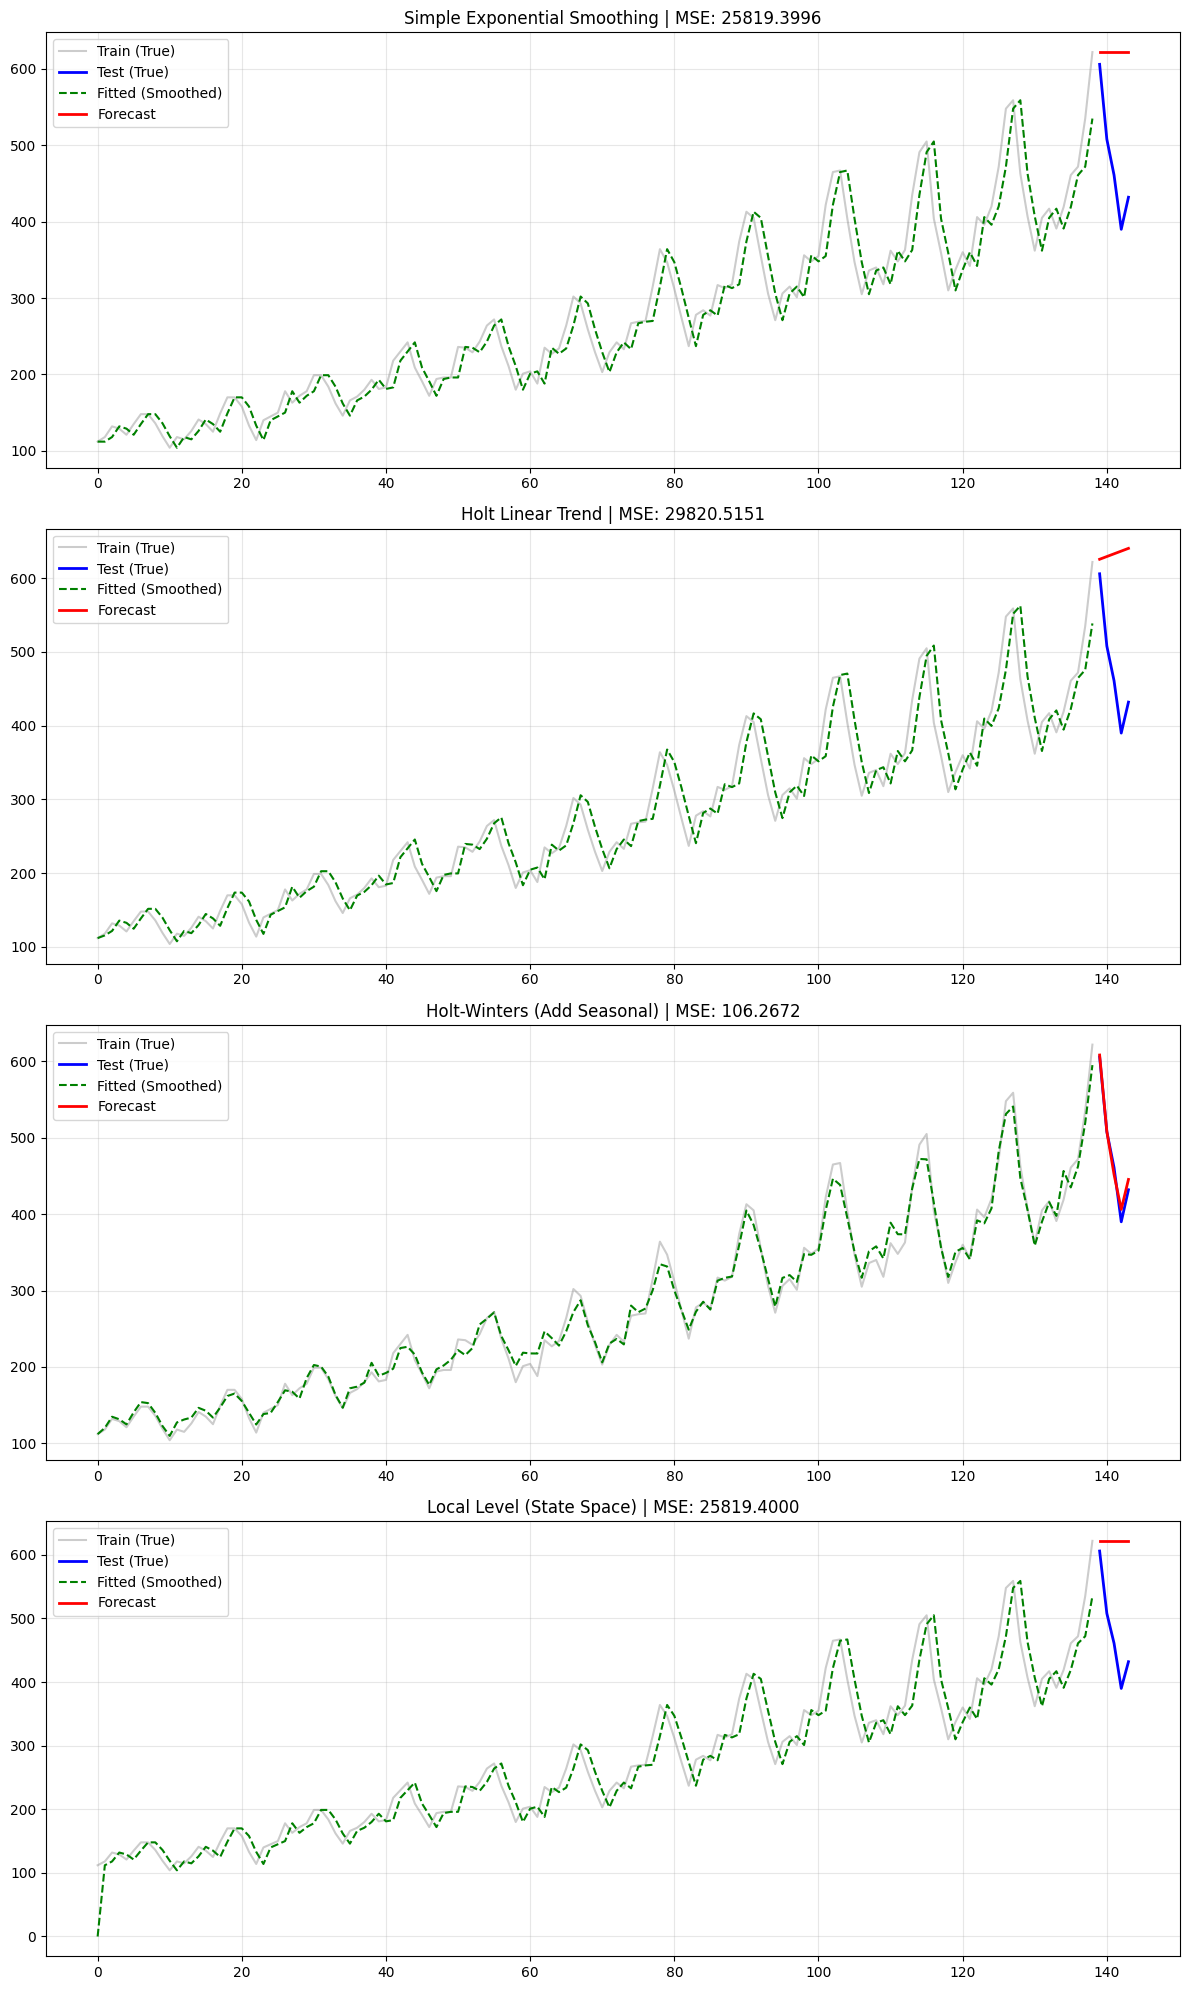

In [30]:
test_smoothening(ts1_train,ts1_test)

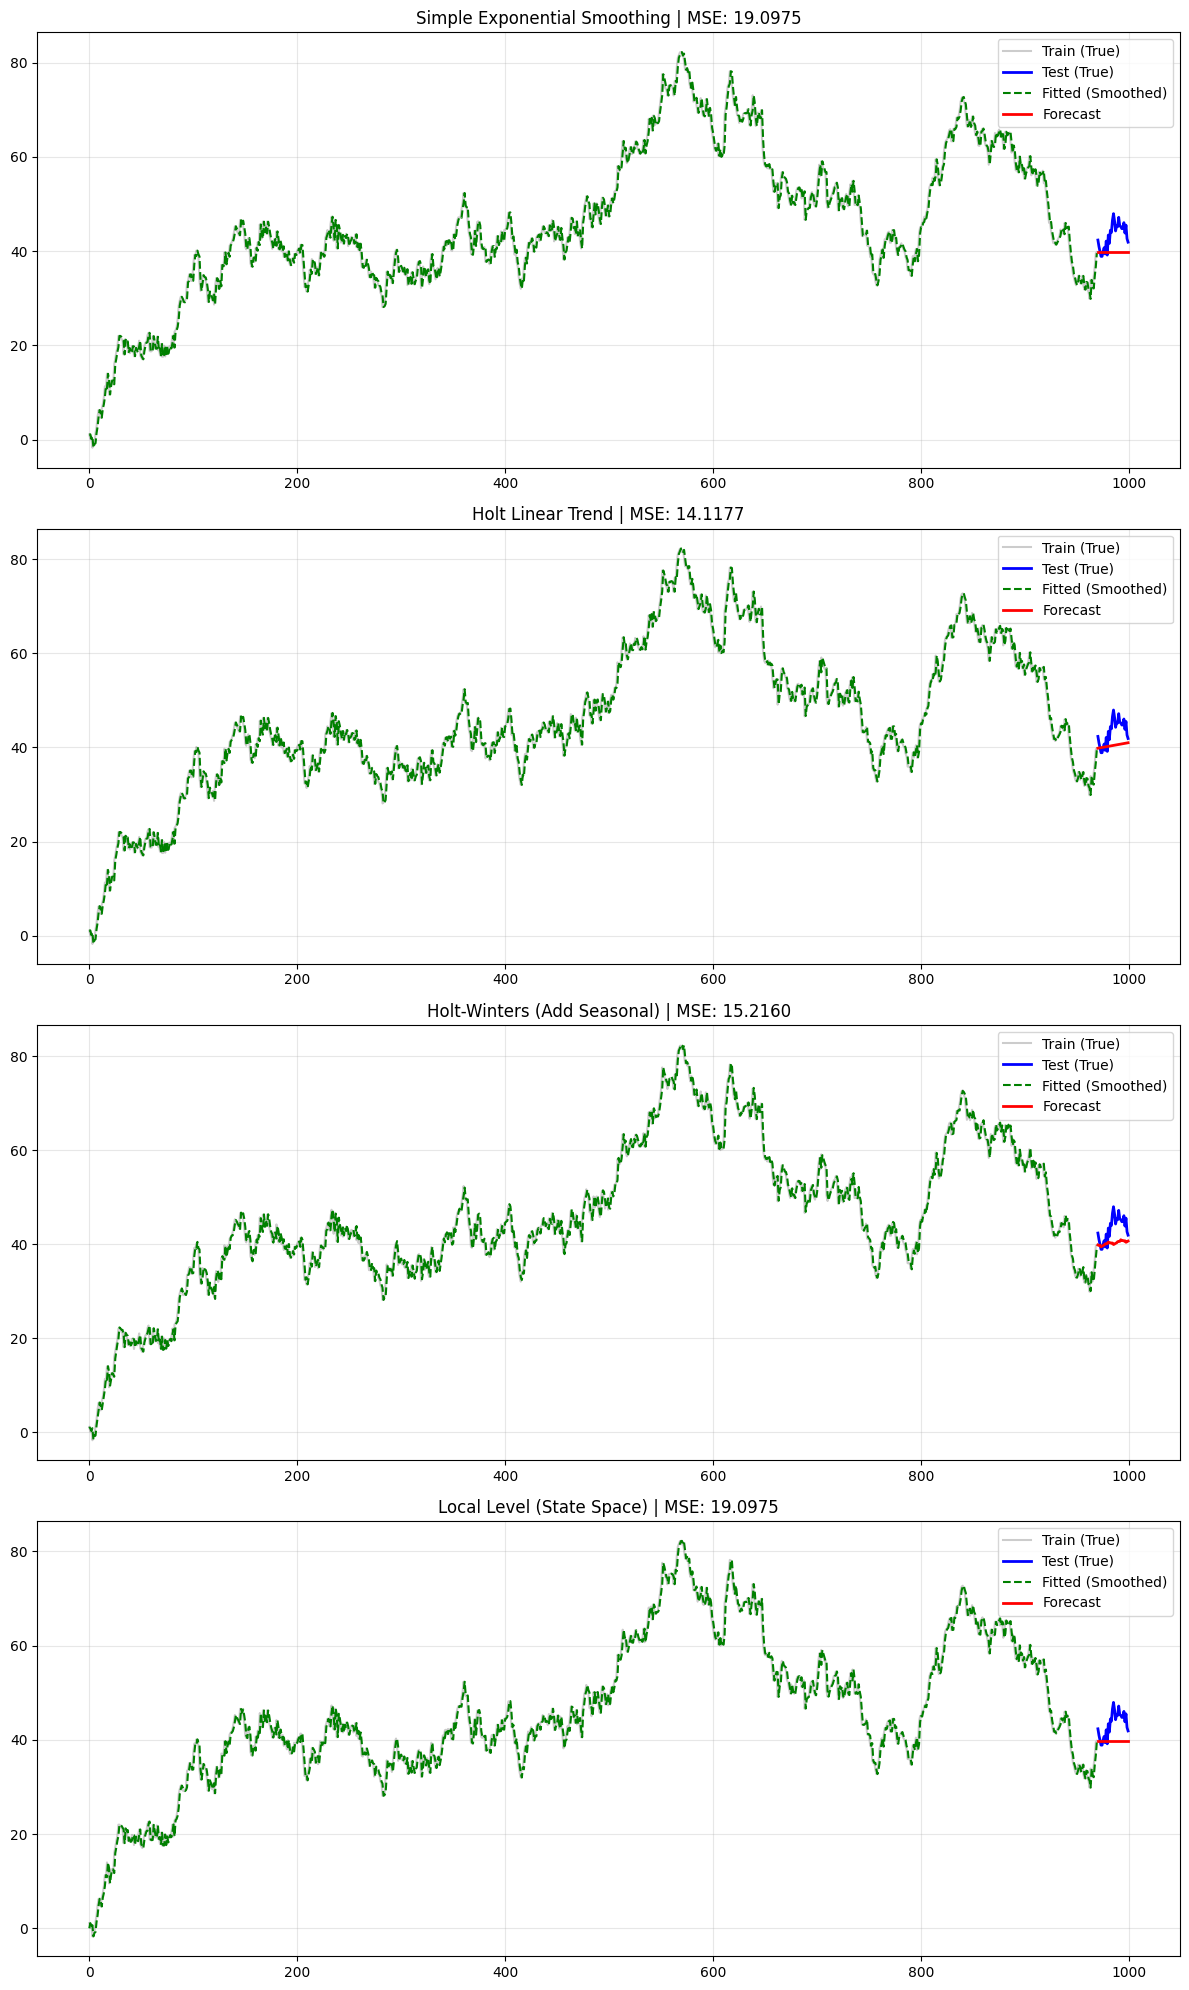

In [35]:
test_smoothening(ts2_train,ts2_test)